In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
import time
import math
import datetime
import warnings
from pathlib import Path

import numpy as np

import torch
import torch.nn as nn
import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2
from torch.utils.data import DataLoader, default_collate

import sys
sys.path.append('../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.torch_video.utils.plotting import plot_all
from computer_vision.torch_video.utils.progress import MetricLogger, SmoothedValue, form_stats, save_metrics
from computer_vision.torch_video.utils.metrics import accuracy
from computer_vision.torch_video.utils.torch_utils import reduce_across_processes, initialize_weights, seed_worker, save_checkpoint, clear_memory, init_seeds,\
init_distributed_mode, load_checkpoint
from computer_vision.torch_video.data.dataset import UCF101, ConvertTCHWtoCTHW, DATA_MEAN, DATA_STD, NUM_CLASSES
from computer_vision.torch_video.data.sampler import RandomClipSampler, UniformClipSampler

from computer_vision.torch_video.parameter_parser import parser

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask'
metadata_path=data_dirpath/'metadata.pt'

mini_train=True
if not mini_train:
    output_dirpath=Path('D:/results/ucf101/slow_fast/train') 
    arguments= f"""-d {root} -a {annotation_path} -m {metadata_path} -o {output_dirpath} 
    --data-fold 1 --frame-rate 16 --clip-duration 2 --step-duration 1.7 
    --num-ffmpeg-threads 16 --batch-size 16 --nbs 64 --lr 0.005 --momentum 0.9 --warmup_momentum 0.85
    --print-freq 100 --plot-freq 5 --time 21 --epochs 200 
    --device cuda
    """ # --use-cutmix-mixup
else:
    output_dirpath=Path('D:/results/ucf101/slow_fast/mini_train') 
    arguments= f"""-d {root} -a {annotation_path} -m {metadata_path} -o {output_dirpath}
    --data-fold 1 --frame-rate 16 --clip-duration 2 --step-duration 1.7 
    --num-ffmpeg-threads 16 --batch-size 16 --nbs 64  --lr 0.005 --momentum 0.9 --warmup_momentum 0.85
    --print-freq 2 --plot-freq 2 --time 14  --n-batches 4 --epochs 2
    --device cuda
    """ # --use-cutmix-mixup --time 18
args=parser.parse_args(arguments.split())

In [4]:
# Data loader
train_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=True, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='random', use_audio=False,
                     decoder_transforms=[v2.RandomCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.RandomHorizontalFlip(p=args.hflip_prob),
                         ])
                    ) 

val_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=False, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='regular', use_audio=False,
                     decoder_transforms=[v2.CenterCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=None
                    ) 

In torch_video.data.dataset.UCF101.__init__ frame_rate 16.0, clip_duration 2.0
In torch_video.data.dataset.VideoClipMetadata.subset num_frames_per_clip 32
In torch_video.data.dataset.UCF101.__init__ frame_rate 16.0, clip_duration 2.0
In torch_video.data.dataset.VideoClipMetadata.subset num_frames_per_clip 32


In [5]:
train_data_batch=train_dataset[0]
type(train_data_batch), len(train_data_batch), [x.shape if isinstance(x, torch.Tensor) else x for x in train_data_batch]

(tuple,
 4,
 [torch.Size([32, 3, 180, 180]),
  0,
  0,
  {'video_fps': 16.0,
   'video_path': 'D:\\data\\UCF101\\UCF-101\\ApplyEyeMakeup\\v_ApplyEyeMakeup_g08_c01.avi',
   'class': 'ApplyEyeMakeup'}])

In [6]:
val_data_batch=val_dataset[0]
type(val_data_batch), len(val_data_batch), [x.shape if isinstance(x, torch.Tensor) else x for x in val_data_batch]

(tuple,
 4,
 [torch.Size([32, 3, 180, 180]),
  0,
  0,
  {'video_fps': 16.0,
   'video_path': 'D:\\data\\UCF101\\UCF-101\\ApplyEyeMakeup\\v_ApplyEyeMakeup_g01_c01.avi',
   'class': 'ApplyEyeMakeup'}])

In [7]:
make_grid(train_data_batch[0]).shape

torch.Size([3, 730, 1458])

(np.float64(-0.5), np.float64(1457.5), np.float64(729.5), np.float64(-0.5))

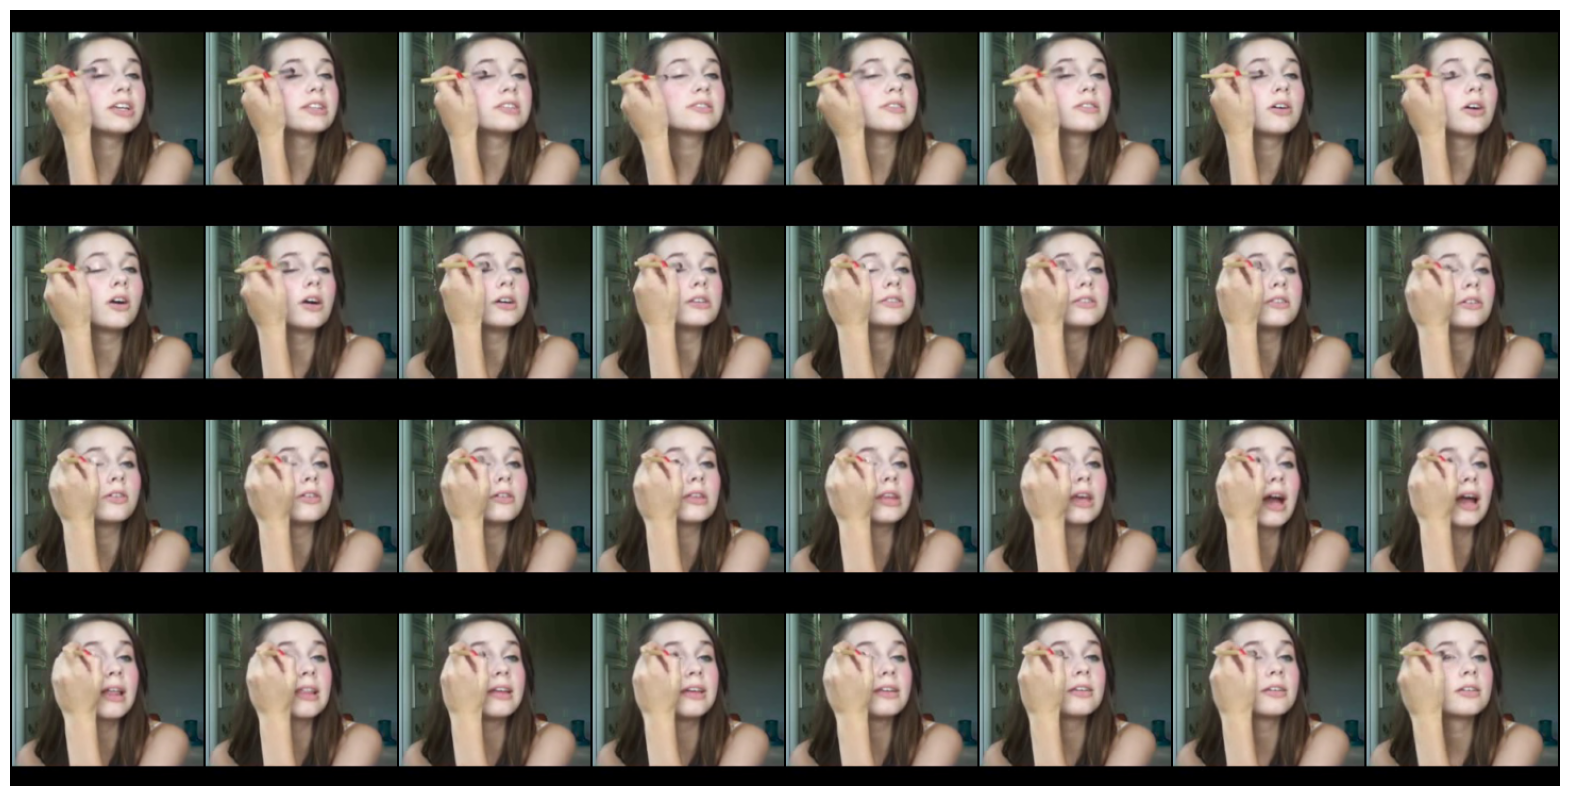

In [8]:
#(T,C,H,W)
_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(train_data_batch[0]).permute(1,2,0))
ax.axis("off")

(np.float64(-0.5), np.float64(1457.5), np.float64(729.5), np.float64(-0.5))

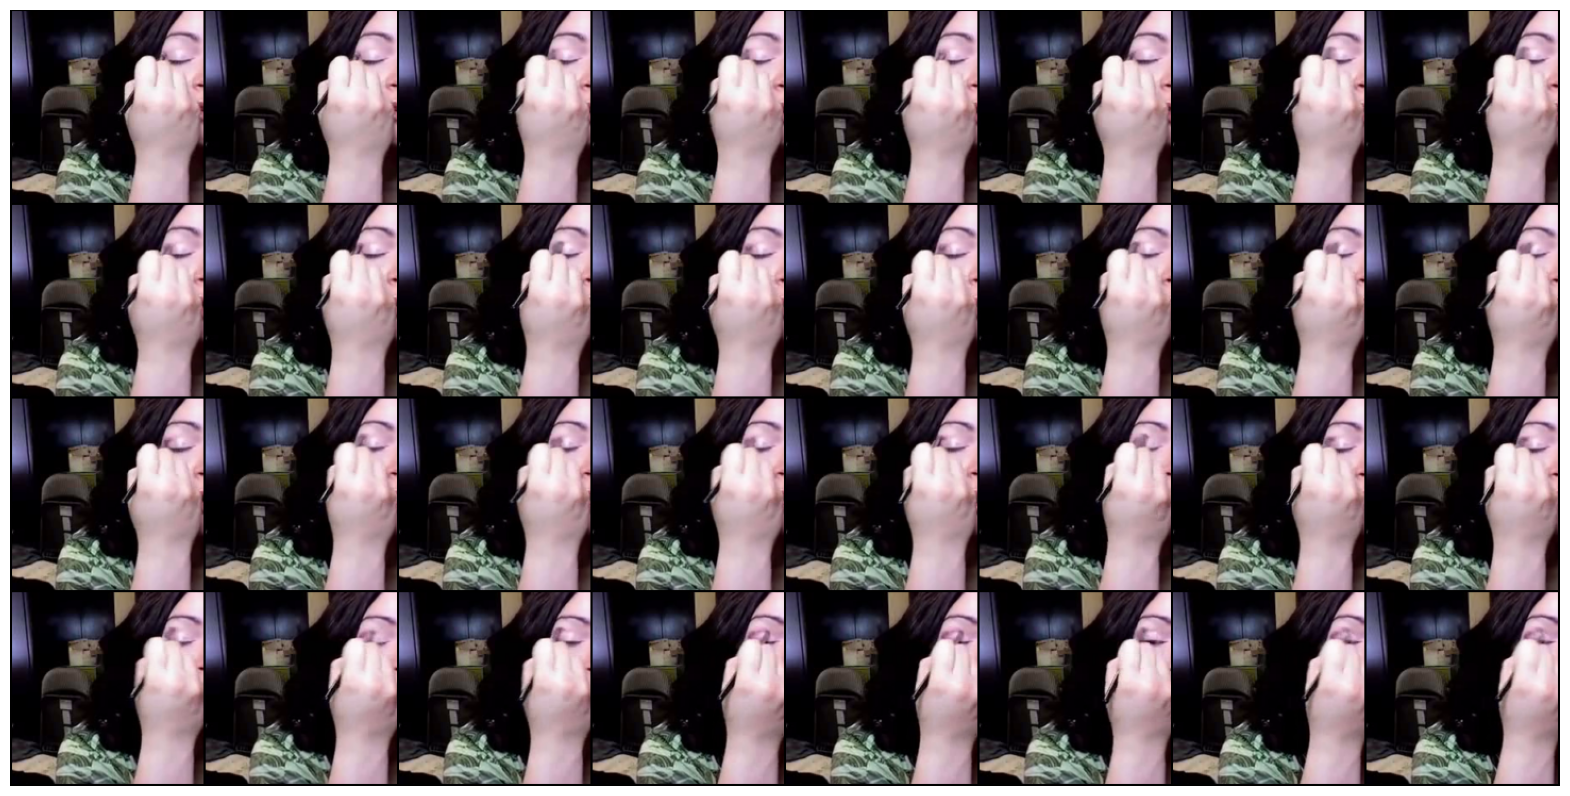

In [9]:
#(T,C,H,W)
_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(val_data_batch[0]).permute(1,2,0))
ax.axis("off")